In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")
 
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

def set_seed(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


In [2]:
DATA_DIR    = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR     = "/kaggle/working/task3_exp5_gpnsd"
LATENT_DIM  = 16
N_CLASSES   = 2
DIG_MAP     = {1: 0, 2: 1}
 
EPOCHS_ORACLE = 20          # Phase 1 oracle training
EPOCHS_REFINE = 60          # Phase B neural refinement (fewer than prior exps — warm start)
BATCH_SIZE    = 256
LR_ORACLE     = 1e-3
LR_REFINE     = 3e-4        # slightly higher since generators start near optimum
 
NG            = 3           # discover 3 symmetry directions (spectral gap reveals true count)
 
EPS_VERIFY    = 0.05        # integration step for orbit evaluation
SPECTRAL_REG  = 1e-4        # regulariser for (J_ψ J_ψᵀ)⁻¹
N_ORBIT_STEPS = 14          # orbit integration steps in evaluation
 
W_PERP  = 2.0
W_NORM  = 0.5
W_ORTHO = 0.5
W_SYM   = 0.1
 
TASK1_CKPT = "/kaggle/input/models/vitthal2945/e2e-vaemodel/pytorch/default/1/best_model.pt"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/task3_exp5_gpnsd


In [3]:
def load_h5(path: str):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1).clamp(0., 1.)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    print(f"done ({time.time()-t0:.1f}s)")
    return imgs, labels, angles
 
train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))
 
def binary_filter(imgs, lbls, angs):
    mask = (lbls == 1) | (lbls == 2)
    return imgs[mask], lbls[mask], angs[mask]
 
tr_imgs, tr_lbls, tr_angs = binary_filter(train_imgs, train_lbls, train_angs)
te_imgs, te_lbls, te_angs = binary_filter(test_imgs,  test_lbls,  test_angs)
tr_cls = torch.tensor([DIG_MAP[l.item()] for l in tr_lbls])
te_cls = torch.tensor([DIG_MAP[l.item()] for l in te_lbls])

  loading rotated_mnist_train.h5 ... done (2.2s)
  loading rotated_mnist_test.h5 ... done (0.4s)


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))
 
class T1Encoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.GroupNorm(8, 32), nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,  64, 4, 2, 1, bias=False), nn.GroupNorm(8, 64), nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64, 128, 3, 2, 1, bias=False), nn.GroupNorm(8, 128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, ld)
        self.fc_lv = nn.Linear(512, ld)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x)))); h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)
 
class T1Decoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ld, 512), nn.SiLU(), nn.Linear(512, 128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.GroupNorm(8, 64), nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.GroupNorm(8, 32), nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32, 1, 4, 2, 3), nn.Sigmoid())
    def forward(self, z): return self.u3(self.u2(self.u1(self.fc(z).view(-1, 128, 4, 4))))
 
class Task1VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.encoder = T1Encoder(ld)
        self.decoder = T1Decoder(ld)
    def encode(self, x): mu, _ = self.encoder(x); return mu
    def decode(self, z): return self.decoder(z)
 
vae = Task1VAE(LATENT_DIM).to(device)
if os.path.exists(TASK1_CKPT):
    ck = torch.load(TASK1_CKPT, map_location=device, weights_only=False)
    vae.load_state_dict(ck["model"])
    print(f"Task-1 VAE loaded (epoch {ck['epoch']})")
else:
    print("⚠  TASK1_CKPT not found — set the correct path!")
vae.eval()
for p in vae.parameters(): p.requires_grad = False
 
@torch.no_grad()
def encode_split(imgs, cls_labels, batch=512):
    Z, C = [], []
    for i in range(0, len(imgs), batch):
        Z.append(vae.encode(imgs[i:i+batch].to(device)).cpu())
        C.append(cls_labels[i:i+batch])
    return torch.cat(Z), torch.cat(C)
 
print("Pre-encoding latent codes …")
Z_tr, C_tr = encode_split(tr_imgs, tr_cls)
Z_te, C_te = encode_split(te_imgs, te_cls)
print(f"Latent codes: train {Z_tr.shape}  test {Z_te.shape}")
 
z_tr_loader = DataLoader(TensorDataset(Z_tr, C_tr), batch_size=BATCH_SIZE, shuffle=True)

Task-1 VAE loaded (epoch 47)
Pre-encoding latent codes …
Latent codes: train torch.Size([152400, 16])  test torch.Size([26004, 16])


In [5]:
class BinaryOracle(nn.Module):
    def __init__(self, ld=LATENT_DIM, nc=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ld, 256), nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, nc),
        )
    def forward(self, z): return self.net(z)
 
psi = BinaryOracle().to(device)
opt_psi   = torch.optim.Adam(psi.parameters(), lr=LR_ORACLE, weight_decay=1e-5)
sched_psi = torch.optim.lr_scheduler.CosineAnnealingLR(opt_psi, T_max=EPOCHS_ORACLE)
 
print(f"\n─── Phase 1: Training oracle ψ for {EPOCHS_ORACLE} epochs ───")
for ep in range(1, EPOCHS_ORACLE + 1):
    psi.train()
    for z, c in z_tr_loader:
        z, c = z.to(device), c.to(device)
        opt_psi.zero_grad()
        F.cross_entropy(psi(z), c).backward()
        opt_psi.step()
    sched_psi.step()
    if ep % 5 == 0 or ep == 1:
        psi.eval()
        with torch.no_grad():
            acc = (psi(Z_te[:2000].to(device)).argmax(1) ==
                   C_te[:2000].to(device)).float().mean().item()
        psi.train()
        print(f"  ep {ep:3d}/{EPOCHS_ORACLE}  val_acc={acc:.4f}")
 
psi.eval()
for p in psi.parameters(): p.requires_grad = False
print("Oracle frozen.\n")


─── Phase 1: Training oracle ψ for 20 epochs ───
  ep   1/20  val_acc=0.9985
  ep   5/20  val_acc=0.9980
  ep  10/20  val_acc=0.9975
  ep  15/20  val_acc=0.9970
  ep  20/20  val_acc=0.9960
Oracle frozen.



In [6]:
def oracle_gradient(z: torch.Tensor, create_graph: bool = False) -> torch.Tensor:
    with torch.enable_grad():
        z_in  = z.detach().requires_grad_(True)
        psi_z = psi(z_in)
        rows  = []
        for c in range(N_CLASSES):
            g = torch.autograd.grad(
                psi_z[:, c].sum(), z_in,
                create_graph=create_graph,
                retain_graph=(c < N_CLASSES - 1) or create_graph
            )[0]
            rows.append(g)
    return torch.stack(rows, dim=1).detach()   # (B, k, d) — always detached

In [7]:
def compute_mean_null_projector(Z_data: torch.Tensor,
                                 batch_size: int = 512) -> torch.Tensor:
    """
    Batched computation of E_z[P_z] over the dataset.
 
    Returns P_mean ∈ R^{d×d}, symmetrised for numerical stability.
    """
    d = Z_data.shape[1]
    S = torch.zeros(d, d, device="cpu")   # accumulate E[J^T (JJT)^{-1} J]
    n_total = 0
 
    for i in range(0, len(Z_data), batch_size):
        z_b = Z_data[i:i+batch_size]
        J   = oracle_gradient(z_b.to(device))  # (B, k, d)
 
        JJT = torch.bmm(J, J.transpose(1, 2))  # (B, k, k) — 2×2 matrices
        reg = SPECTRAL_REG * torch.eye(N_CLASSES, device=device).unsqueeze(0)
        JJT_inv = torch.linalg.inv(JJT + reg)   # (B, k, k)
 
        # Σ_z J_z^T (J_z J_z^T)^{-1} J_z   ∈ R^{d×d}
        JT_JJTinv = torch.bmm(J.transpose(1, 2), JJT_inv)  # (B, d, k)
        S += torch.bmm(JT_JJTinv, J).sum(0).cpu()           # (d, d)
        n_total += len(z_b)
 
    P_mean = torch.eye(d) - S / n_total       # E[P_z] = I − E[J^T(JJT)⁻¹J]
    P_mean = (P_mean + P_mean.T) / 2          # symmetrise for stable eig
    return P_mean
 
 
print("─── Phase A: Projected Null-Space Spectral Analysis ───")
t0 = time.time()
P_mean = compute_mean_null_projector(Z_tr)
print(f"  E[P_z] computed in {time.time()-t0:.1f}s  (shape {tuple(P_mean.shape)})")
 
# Eigendecomposition — eigh guarantees real eigenvalues, ascending order
eigenvalues, eigenvectors = torch.linalg.eigh(P_mean)   # (d,), (d, d)
 
# Sort descending: highest eigenvalue = strongest global symmetry
idx = eigenvalues.argsort(descending=True)
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]   # columns are eigenvectors
 
# Global symmetry directions: top NG eigenvectors (rows for convenience)
global_dirs = eigenvectors[:, :NG].T.contiguous()   # (NG, d)
 
# Spectral gap after rank NG reveals the symmetry group dimension
spectral_gap = (eigenvalues[NG - 1] - eigenvalues[NG]).item()
 
print(f"\n  Eigenvalue spectrum (top {NG + 3}):")
for i, lam in enumerate(eigenvalues[:NG + 3]):
    tag = " ← SEM" if i < NG else ("  ← gap" if i == NG else "")
    print(f"    λ_{i+1:02d} = {lam.item():.5f}{tag}")
print(f"\n  Spectral gap after rank {NG}: Δ = {spectral_gap:.5f}")
print(f"  (Large gap → symmetry group dimension ≤ {NG})\n")
 
# Symmetry Equivariance Measures
SEMs = eigenvalues[:NG].tolist()

─── Phase A: Projected Null-Space Spectral Analysis ───
  E[P_z] computed in 0.8s  (shape (16, 16))

  Eigenvalue spectrum (top 6):
    λ_01 = 0.98994 ← SEM
    λ_02 = 0.98691 ← SEM
    λ_03 = 0.98085 ← SEM
    λ_04 = 0.97084  ← gap
    λ_05 = 0.96809
    λ_06 = 0.96010

  Spectral gap after rank 3: Δ = 0.01001
  (Large gap → symmetry group dimension ≤ 3)



In [8]:
class SpectralRefinementGenerator(nn.Module):
    def __init__(self, ld: int, global_dir: torch.Tensor, hidden: int = 256):
        super().__init__()
        # Frozen spectral prior — registered as buffer so it moves with device
        self.register_buffer("v", F.normalize(global_dir.float(), dim=0))
 
        # Learnable correction scale (initialised small: exp(-2.3) ≈ 0.1)
        self.log_scale = nn.Parameter(torch.tensor(-2.3))
 
        # Correction MLP: z → δ ∈ R^d
        self.delta = nn.Sequential(
            nn.Linear(ld, hidden),      nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden),  nn.GELU(),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Linear(hidden // 2, ld),
        )
        # Tiny init so G ≈ v at the start of Phase B
        nn.init.uniform_(self.delta[-1].weight, -0.002, 0.002)
        nn.init.zeros_(self.delta[-1].bias)
 
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """Returns G_α(z) = v_α + scale·δ_α(z)   shape (B, d), unnormalized."""
        scale = torch.exp(self.log_scale)
        delta = scale * self.delta(z)                              # (B, d)
        return self.v.unsqueeze(0).expand(len(z), -1) + delta     # (B, d)
 
    def get_correction(self, z: torch.Tensor) -> torch.Tensor:
        return torch.exp(self.log_scale) * self.delta(z)
 
 
# Build one generator per top eigenvector
generators = [SpectralRefinementGenerator(LATENT_DIM, global_dirs[i]).to(device)
              for i in range(NG)]
 
for i, G in enumerate(generators):
    n_params = sum(p.numel() for p in G.parameters())
    print(f"G_{i+1}  SEM={SEMs[i]:.4f}  dir={global_dirs[i][:4].numpy().round(3).tolist()}…  "
          f"params={n_params:,}")
 
all_gen_params = [p for G in generators for p in G.parameters()]
opt_G = torch.optim.AdamW(all_gen_params, lr=LR_REFINE, weight_decay=1e-5)
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=EPOCHS_REFINE)

G_1  SEM=0.9899  dir=[0.16099999845027924, -0.23000000417232513, -0.11599999666213989, -0.035999998450279236]…  params=105,617
G_2  SEM=0.9869  dir=[-0.18700000643730164, 0.00800000037997961, -0.29899999499320984, -0.38100001215934753]…  params=105,617
G_3  SEM=0.9809  dir=[-0.02800000086426735, 0.46799999475479126, -0.11599999666213989, 0.43799999356269836]…  params=105,617


In [9]:
def l_perp(G_vec: torch.Tensor, grad_psi: torch.Tensor) -> torch.Tensor:
    """||∇ψ · G||²  — G must lie in the null space of the oracle Jacobian."""
    dot = torch.bmm(grad_psi, G_vec.unsqueeze(2)).squeeze(2)   # (B, k)
    return (dot ** 2).mean()
 
def l_norm(G_vec: torch.Tensor) -> torch.Tensor:
    """(||G|| − 1)²  — unit-speed parametrisation."""
    return ((G_vec.norm(dim=1) - 1.0) ** 2).mean()
 
def l_ortho(G_vecs: list) -> torch.Tensor:
    """Σ_{α<β} (G_α · G_β)²  — discover independent directions."""
    if len(G_vecs) < 2:
        return torch.zeros(1, device=G_vecs[0].device).squeeze()
    total = torch.zeros(1, device=G_vecs[0].device).squeeze()
    for i in range(len(G_vecs)):
        for j in range(i + 1, len(G_vecs)):
            dot = (G_vecs[i] * G_vecs[j]).sum(dim=1)
            total = total + (dot ** 2).mean()
    return total
 
def l_sym(corrections: list) -> torch.Tensor:
    """Σ_α ||δ_α(z)||²  — keep corrections close to spectral prior."""
    return sum((c ** 2).mean() for c in corrections) / len(corrections)

In [10]:
history = {k: [] for k in ["perp", "norm", "ortho", "sym", "total",
                             "val_perp", "val_drift"]}
best_val = float("inf")
 
print(f"\n─── Phase B: Neural refinement for {EPOCHS_REFINE} epochs ───\n")
 
for ep in range(1, EPOCHS_REFINE + 1):
    for G in generators: G.train()
    acc = {k: 0. for k in ["perp", "norm", "ortho", "sym"]}
    n_b = 0
 
    for z, _ in z_tr_loader:
        z = z.to(device)
        opt_G.zero_grad(set_to_none=True)
 
        # ── oracle gradient: create_graph=False avoids ALL double-backward issues
        # (grad_psi is a plain tensor; no computation graph built through psi)
        grad_psi = oracle_gradient(z)           # (B, k, d)
 
        # ── forward pass through all generators
        G_vecs  = [G(z) for G in generators]   # list of (B, d), unnormalized
        corrs   = [G.get_correction(z) for G in generators]  # list of (B, d) deltas
 
        # ── losses
        lp = sum(l_perp(gv, grad_psi) for gv in G_vecs) / NG
        ln = sum(l_norm(gv)           for gv in G_vecs) / NG
        lo = l_ortho(G_vecs)
        ls = l_sym(corrs)
 
        loss = W_PERP * lp + W_NORM * ln + W_ORTHO * lo + W_SYM * ls
        loss.backward()
        nn.utils.clip_grad_norm_(all_gen_params, max_norm=1.0)
        opt_G.step()
 
        acc["perp"]  += lp.item()
        acc["norm"]  += ln.item()
        acc["ortho"] += lo.item()
        acc["sym"]   += ls.item()
        n_b += 1
 
    sched_G.step()
    for k in acc: acc[k] /= n_b
    total = W_PERP*acc["perp"] + W_NORM*acc["norm"] + W_ORTHO*acc["ortho"] + W_SYM*acc["sym"]
 
    # ── Validation ──────────────────────────────────────────────────────────
    for G in generators: G.eval()
 
    rand_idx  = torch.randperm(len(Z_te))[:256]
    z_val     = Z_te[rand_idx].to(device)
    gp_val    = oracle_gradient(z_val)          # (B, k, d) — plain tensor
 
    with torch.no_grad():
        gv_val   = generators[0](z_val)         # (B, d)
        dot_val  = torch.bmm(gp_val, gv_val.unsqueeze(2)).squeeze(2)
        val_perp = (dot_val ** 2).mean().item()
 
        # True oracle drift: single Euler step
        psi_0    = psi(z_val)
        z_new    = z_val + EPS_VERIFY * F.normalize(gv_val, dim=1)
        val_drift = F.mse_loss(psi(z_new), psi_0).item()
 
    for G in generators: G.train()
 
    for k in acc: history[k].append(acc[k])
    history["total"].append(total)
    history["val_perp"].append(val_perp)
    history["val_drift"].append(val_drift)
 
    tag = ""
    if val_perp < best_val:
        best_val = val_perp
        torch.save({"generators": [G.state_dict() for G in generators],
                    "oracle": psi.state_dict(),
                    "global_dirs": global_dirs,
                    "eigenvalues": eigenvalues,
                    "epoch": ep, "best_val_perp": best_val},
                   os.path.join(OUT_DIR, "best_model.pt"))
        tag = "  ★"
 
    if ep % 10 == 0 or ep <= 3 or tag:
        print(f"  ep {ep:3d}/{EPOCHS_REFINE}  "
              f"perp={acc['perp']:.5f}  norm={acc['norm']:.5f}  "
              f"ortho={acc['ortho']:.5f}  sym={acc['sym']:.5f}  "
              f"val_perp={val_perp:.5f}  val_drift={val_drift:.5f}{tag}")
 
# Load best checkpoint
ck = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
for i, G in enumerate(generators):
    G.load_state_dict(ck["generators"][i]); G.eval()
print(f"\nBest model loaded (epoch {ck['epoch']}, val_perp={ck['best_val_perp']:.5f})\n")


─── Phase B: Neural refinement for 60 epochs ───

  ep   1/60  perp=0.40542  norm=0.36860  ortho=0.00028  sym=0.02608  val_perp=0.05159  val_drift=0.00269  ★
  ep   2/60  perp=0.04319  norm=0.35923  ortho=0.00204  sym=0.02897  val_perp=0.04636  val_drift=0.00153  ★
  ep   3/60  perp=0.04127  norm=0.30725  ortho=0.00330  sym=0.02910  val_perp=0.05011  val_drift=0.00161
  ep   4/60  perp=0.04040  norm=0.27590  ortho=0.00395  sym=0.02985  val_perp=0.03134  val_drift=0.00058  ★
  ep   8/60  perp=0.03675  norm=0.21662  ortho=0.00718  sym=0.03239  val_perp=0.03069  val_drift=0.00070  ★
  ep  10/60  perp=0.03589  norm=0.20032  ortho=0.00803  sym=0.03295  val_perp=0.03304  val_drift=0.00046
  ep  16/60  perp=0.03380  norm=0.15848  ortho=0.00782  sym=0.03421  val_perp=0.02532  val_drift=0.00053  ★
  ep  20/60  perp=0.03321  norm=0.13752  ortho=0.00694  sym=0.03457  val_perp=0.04461  val_drift=0.00038
  ep  29/60  perp=0.03142  norm=0.10644  ortho=0.00432  sym=0.03533  val_perp=0.02517  val_dri

In [11]:
@torch.no_grad()
def midpoint_step(z: torch.Tensor, G_net: nn.Module, eps: float = EPS_VERIFY) -> torch.Tensor:
    gv_0  = F.normalize(G_net(z), dim=1)      # G at z
    z_mid = z + (eps / 2) * gv_0              # half step
    gv_m  = F.normalize(G_net(z_mid), dim=1)  # G at midpoint
    return z + eps * gv_m                     # full step with midpoint velocity

In [12]:
def evaluate():
    for G in generators: G.eval()
 
    rand_idx = torch.randperm(len(Z_te))[:500]
    z_val    = Z_te[rand_idx].to(device)
    gp_val   = oracle_gradient(z_val)   # (B, k, d)
 
    # M1: Perpendicularity residual per generator
    perp_vals = []
    with torch.no_grad():
        for G in generators:
            gv  = G(z_val)
            dot = torch.bmm(gp_val, gv.unsqueeze(2)).squeeze(2)
            perp_vals.append((dot ** 2).mean().item())
 
    # M2: Oracle drift over N_ORBIT_STEPS using midpoint integration
    drift_orbits = []
    for G in generators:
        with torch.no_grad():
            psi_0  = psi(z_val)
        z_t    = z_val.clone()
        drifts = []
        for _ in range(N_ORBIT_STEPS):
            z_t = midpoint_step(z_t, G)
            with torch.no_grad():
                drifts.append(F.mse_loss(psi(z_t), psi_0).item())
        drift_orbits.append(drifts)
 
    # M3: Spectral alignment — how well do refined generators align with priors?
    with torch.no_grad():
        spectral_align = []
        for i, G in enumerate(generators):
            gv = F.normalize(G(z_val), dim=1)   # (B, d)
            v  = G.v.unsqueeze(0).expand(len(z_val), -1)
            cos_sim = (gv * v).sum(dim=1).abs().mean().item()
            spectral_align.append(cos_sim)
 
    # M4: Lie bracket residual [G_α, G_β](z) ≈ 0 for abelian symmetry
    # [G_α, G_β](z) = J_{G_β}(z)·G_α(z) − J_{G_α}(z)·G_β(z)
    # Estimated via finite differences with step h
    lie_residuals = {}
    h = 1e-3
    with torch.no_grad():
        z_sub = z_val[:128]
        for a in range(NG):
            for b in range(a + 1, NG):
                ga  = F.normalize(generators[a](z_sub), dim=1)
                gb  = F.normalize(generators[b](z_sub), dim=1)
                # J_{G_b}·G_a via finite difference
                gb_za = F.normalize(generators[b](z_sub + h * ga), dim=1)
                gb_zm = F.normalize(generators[b](z_sub - h * ga), dim=1)
                Jgb_ga = (gb_za - gb_zm) / (2 * h)
                # J_{G_a}·G_b
                ga_zb = F.normalize(generators[a](z_sub + h * gb), dim=1)
                ga_zm = F.normalize(generators[a](z_sub - h * gb), dim=1)
                Jga_gb = (ga_zb - ga_zm) / (2 * h)
                bracket = Jgb_ga - Jga_gb
                lie_residuals[f"[G{a+1},G{b+1}]"] = bracket.norm(dim=1).mean().item()
 
    return perp_vals, drift_orbits, spectral_align, lie_residuals
 
perp_vals, drift_orbits, spectral_align, lie_residuals = evaluate()
 
# M5: Rotation discovery (post-hoc via angle labels — never used in training)
def rotation_alignment():
    from torchvision.transforms.functional import rotate as tvrotate
    from torchvision import transforms as T
 
    pool = (te_angs == 0).nonzero(as_tuple=True)[0][:200]
    x0   = te_imgs[pool].to(device)
    x30  = tvrotate(x0, 30., interpolation=T.InterpolationMode.BILINEAR, fill=[0.])
 
    with torch.no_grad():
        z0  = vae.encode(x0)
        z30 = vae.encode(x30)
    rot = F.normalize(z30 - z0, dim=1)   # true rotation direction in latent space
 
    gp = oracle_gradient(z0)
    sims = []
    with torch.no_grad():
        for G in generators:
            gv   = F.normalize(G(z0), dim=1)
            sims.append(F.cosine_similarity(rot, gv, dim=1).abs().mean().item())
    return sims
 
cos_sims = rotation_alignment()

In [13]:
print("══════════════════ FINAL METRICS ══════════════════")
for i in range(NG):
    print(f"G_{i+1}  [SEM λ={SEMs[i]:.4f}]:")
    print(f"  M1 Perp residual ||∇ψ·G||²      : {perp_vals[i]:.5f}  [→ 0]")
    print(f"  M2 Oracle drift @step {N_ORBIT_STEPS}         : {drift_orbits[i][-1]:.5f}")
    print(f"  M3 Spectral alignment |cos(G,v)| : {spectral_align[i]:.4f}  [near 1 = close to prior]")
    print(f"  M5 Rotation cos-sim (post-hoc)   : {cos_sims[i]:.4f}")
print(f"\nSpectral gap after rank {NG}  : {spectral_gap:.5f}")
print(f"Lie bracket residuals:")
for k, v in lie_residuals.items():
    print(f"  ||{k}||  : {v:.5f}  [→ 0 for abelian symmetry group]")
print("═══════════════════════════════════════════════════")
 
np.save(os.path.join(OUT_DIR, "metrics.npy"), {
    "exp": "EXP5_GPNSD",
    "SEMs": SEMs,
    "spectral_gap": spectral_gap,
    "eigenvalues": eigenvalues[:NG + 4].tolist(),
    "perp_residuals": perp_vals,
    "drift_orbits": drift_orbits,
    "spectral_alignment": spectral_align,
    "lie_residuals": lie_residuals,
    "rotation_cosine_sims": cos_sims,
    "history": {k: history[k] for k in history},
    "global_dirs": global_dirs.tolist(),
}, allow_pickle=True)

══════════════════ FINAL METRICS ══════════════════
G_1  [SEM λ=0.9899]:
  M1 Perp residual ||∇ψ·G||²      : 0.02951  [→ 0]
  M2 Oracle drift @step 14         : 1.28417
  M3 Spectral alignment |cos(G,v)| : 0.6521  [near 1 = close to prior]
  M5 Rotation cos-sim (post-hoc)   : 0.1853
G_2  [SEM λ=0.9869]:
  M1 Perp residual ||∇ψ·G||²      : 0.03224  [→ 0]
  M2 Oracle drift @step 14         : 0.87096
  M3 Spectral alignment |cos(G,v)| : 0.6262  [near 1 = close to prior]
  M5 Rotation cos-sim (post-hoc)   : 0.2349
G_3  [SEM λ=0.9809]:
  M1 Perp residual ||∇ψ·G||²      : 0.03130  [→ 0]
  M2 Oracle drift @step 14         : 0.91057
  M3 Spectral alignment |cos(G,v)| : 0.6628  [near 1 = close to prior]
  M5 Rotation cos-sim (post-hoc)   : 0.3822

Spectral gap after rank 3  : 0.01001
Lie bracket residuals:
  ||[G1,G2]||  : 1.07692  [→ 0 for abelian symmetry group]
  ||[G1,G3]||  : 0.98903  [→ 0 for abelian symmetry group]
  ||[G2,G3]||  : 1.02441  [→ 0 for abelian symmetry group]
══════════════

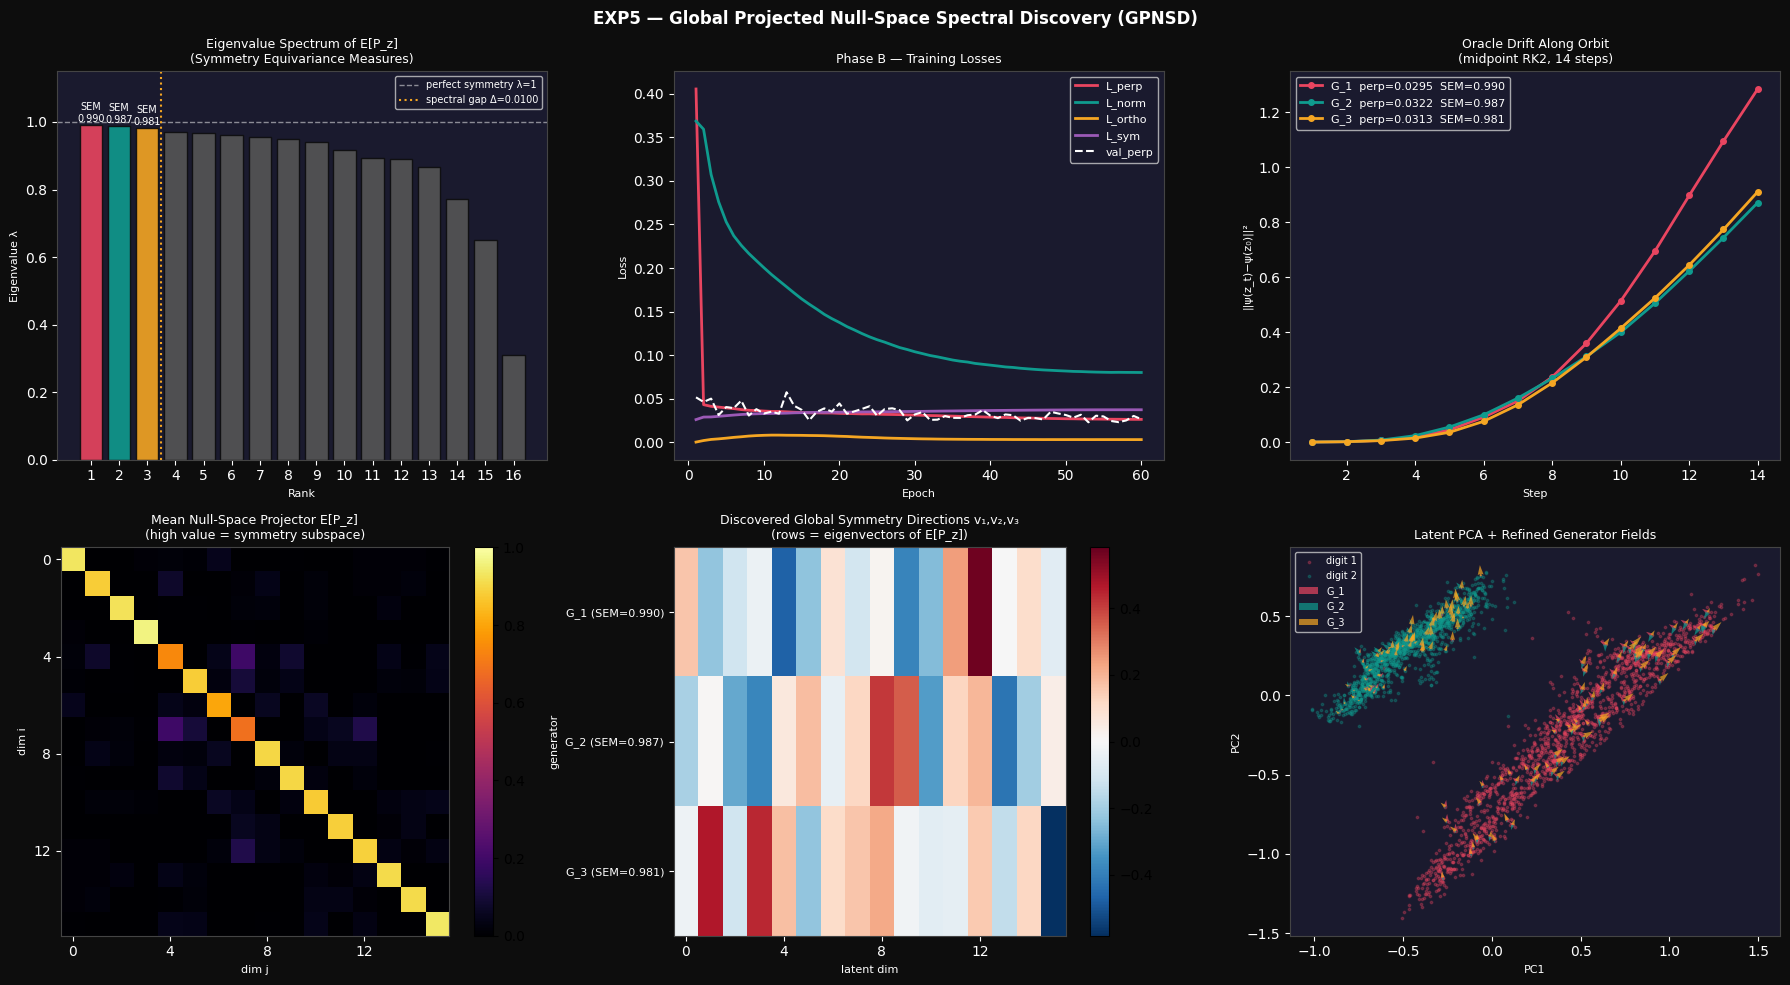

In [14]:
DARK = "#0d0d0d"; PANEL = "#1a1a2e"
CMAP_G = ["#e94560", "#0f9b8e", "#f5a623"]
 
def _ax(ax, title="", xl="", yl=""):
    ax.set_facecolor(PANEL); ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#444")
    if title: ax.set_title(title, color="white", fontsize=9)
    if xl:    ax.set_xlabel(xl, color="white", fontsize=8)
    if yl:    ax.set_ylabel(yl, color="white", fontsize=8)
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=DARK)
fig.suptitle("EXP5 — Global Projected Null-Space Spectral Discovery (GPNSD)",
             color="white", fontsize=12, fontweight="bold")
ep_x = range(1, EPOCHS_REFINE + 1)
 
# Panel 1: Eigenvalue spectrum of E[P_z] (the key analytical result)
_ax(axes[0, 0], "Eigenvalue Spectrum of E[P_z]\n(Symmetry Equivariance Measures)", "Rank", "Eigenvalue λ")
eig_np = eigenvalues[:LATENT_DIM].numpy()
colors_eig = [CMAP_G[i] if i < NG else "#555" for i in range(LATENT_DIM)]
axes[0, 0].bar(range(1, LATENT_DIM + 1), eig_np, color=colors_eig, alpha=0.9, edgecolor=DARK)
axes[0, 0].axhline(1.0, color="white", lw=1, ls="--", alpha=0.5, label="perfect symmetry λ=1")
axes[0, 0].axvline(NG + 0.5, color="#f5a623", lw=1.5, ls=":", label=f"spectral gap Δ={spectral_gap:.4f}")
for i in range(NG):
    axes[0, 0].text(i + 1, eig_np[i] + 0.01, f"SEM\n{eig_np[i]:.3f}",
                    ha="center", fontsize=7, color="white")
axes[0, 0].set_xticks(range(1, LATENT_DIM + 1))
axes[0, 0].legend(facecolor=PANEL, labelcolor="white", fontsize=7)
axes[0, 0].set_ylim(0, 1.15)
 
# Panel 2: Phase B training curves
_ax(axes[0, 1], "Phase B — Training Losses", "Epoch", "Loss")
axes[0, 1].plot(ep_x, history["perp"],     color="#e94560", lw=2, label="L_perp")
axes[0, 1].plot(ep_x, history["norm"],     color="#0f9b8e", lw=2, label="L_norm")
axes[0, 1].plot(ep_x, history["ortho"],    color="#f5a623", lw=2, label="L_ortho")
axes[0, 1].plot(ep_x, history["sym"],      color="#9b59b6", lw=2, label="L_sym")
axes[0, 1].plot(ep_x, history["val_perp"], color="white",  lw=1.5, ls="--", label="val_perp")
axes[0, 1].legend(facecolor=PANEL, labelcolor="white", fontsize=8)
 
# Panel 3: Oracle drift along orbits (midpoint integration)
_ax(axes[0, 2], f"Oracle Drift Along Orbit\n(midpoint RK2, {N_ORBIT_STEPS} steps)", "Step", "||ψ(z_t)−ψ(z₀)||²")
for i, dc in enumerate(drift_orbits):
    axes[0, 2].plot(range(1, N_ORBIT_STEPS + 1), dc,
                    color=CMAP_G[i], lw=2, marker="o", ms=4,
                    label=f"G_{i+1}  perp={perp_vals[i]:.4f}  SEM={SEMs[i]:.3f}")
axes[0, 2].legend(facecolor=PANEL, labelcolor="white", fontsize=8)
 
# Panel 4: Mean null-space projector heatmap E[P_z]
_ax(axes[1, 0], "Mean Null-Space Projector E[P_z]\n(high value = symmetry subspace)", "dim j", "dim i")
P_np = P_mean.numpy()
im = axes[1, 0].imshow(P_np, cmap="inferno", vmin=0., vmax=1.)
plt.colorbar(im, ax=axes[1, 0])
axes[1, 0].set_xticks(range(0, LATENT_DIM, 4))
axes[1, 0].set_yticks(range(0, LATENT_DIM, 4))
 
# Panel 5: Global directions heatmap (the analytical symmetry priors)
_ax(axes[1, 1], "Discovered Global Symmetry Directions v₁,v₂,v₃\n(rows = eigenvectors of E[P_z])", "latent dim", "generator")
gd_np = global_dirs.numpy()
vmax_gd = max(abs(gd_np).max(), 1e-8)
im2 = axes[1, 1].imshow(gd_np, cmap="RdBu_r", vmin=-vmax_gd, vmax=vmax_gd, aspect="auto")
plt.colorbar(im2, ax=axes[1, 1])
axes[1, 1].set_yticks(range(NG))
axes[1, 1].set_yticklabels([f"G_{i+1} (SEM={SEMs[i]:.3f})" for i in range(NG)],
                             color="white", fontsize=8)
axes[1, 1].set_xticks(range(0, LATENT_DIM, 4))
 
# Panel 6: PCA scatter + generator quiver
pca    = PCA(n_components=2).fit(Z_te[:3000].numpy())
z2_all = pca.transform(Z_te[:3000].numpy())
c_all  = C_te[:3000].numpy()
_ax(axes[1, 2], "Latent PCA + Refined Generator Fields", "PC1", "PC2")
axes[1, 2].scatter(z2_all[c_all == 0, 0], z2_all[c_all == 0, 1], s=3, alpha=0.3, color="#e94560", label="digit 1")
axes[1, 2].scatter(z2_all[c_all == 1, 0], z2_all[c_all == 1, 1], s=3, alpha=0.3, color="#0f9b8e", label="digit 2")
 
idx_q = np.random.choice(3000, 150, replace=False)
z_q   = torch.from_numpy(Z_te[:3000][idx_q].numpy()).to(device)
with torch.no_grad():
    for i, G in enumerate(generators):
        gv = F.normalize(G(z_q), dim=1).cpu().numpy() @ pca.components_.T
        axes[1, 2].quiver(z2_all[idx_q, 0], z2_all[idx_q, 1],
                          gv[:, 0], gv[:, 1],
                          color=CMAP_G[i], alpha=0.7, scale=30, width=0.004, label=f"G_{i+1}")
axes[1, 2].legend(facecolor=PANEL, labelcolor="white", fontsize=7)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "results.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

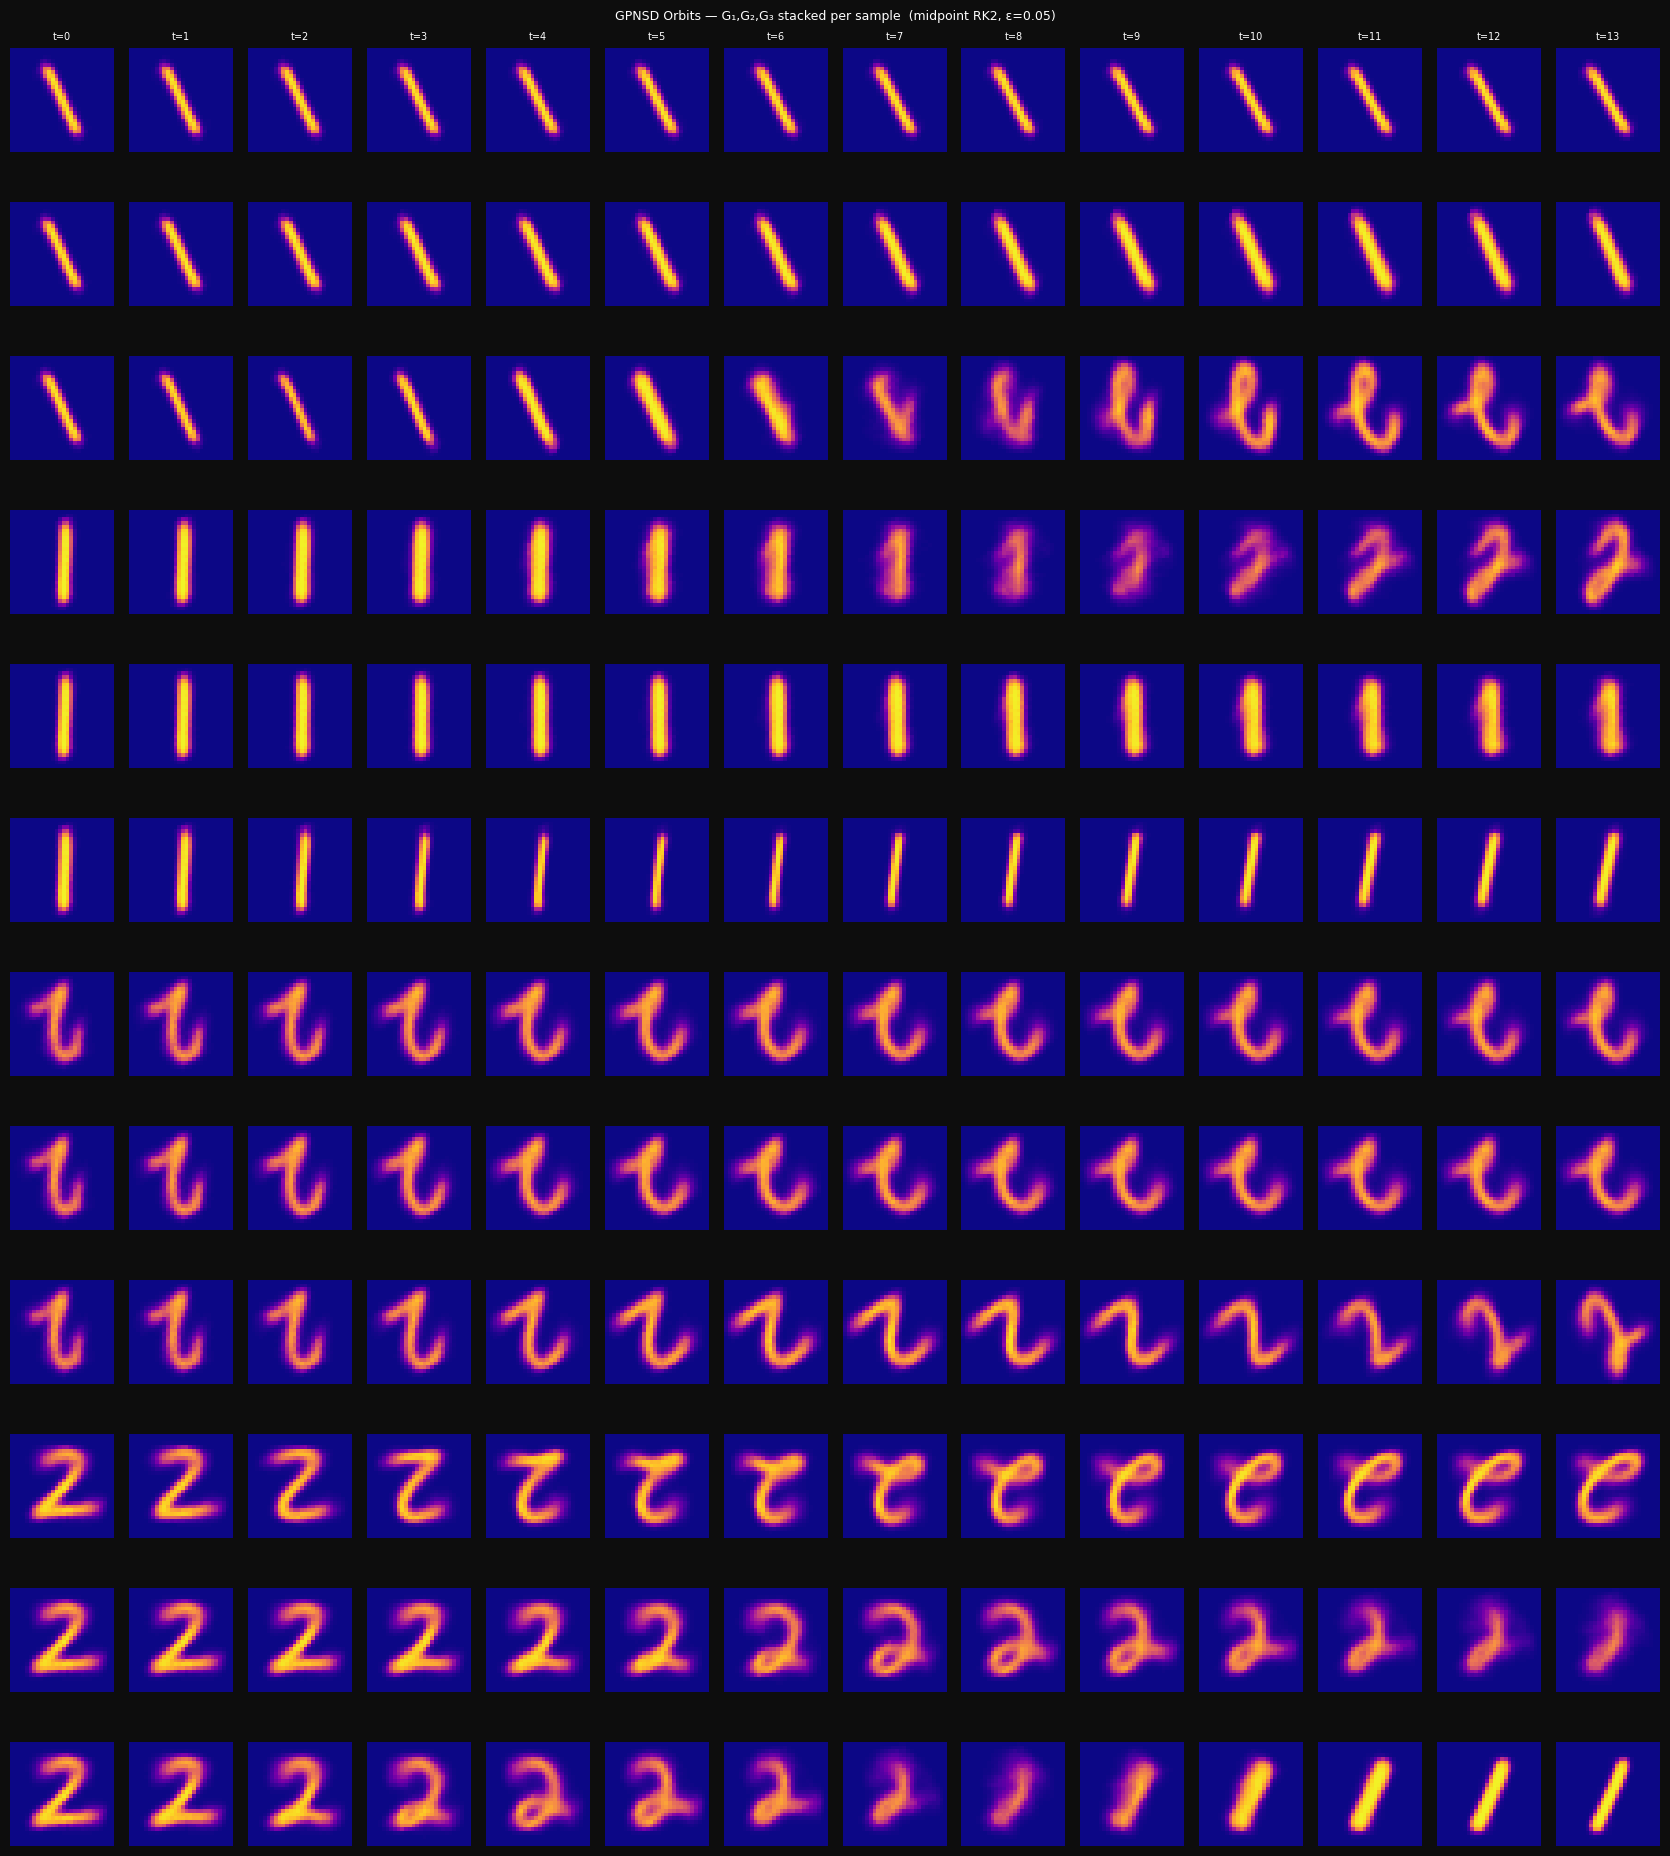


✅ EXP5 — Global Projected Null-Space Spectral Discovery complete
   Best rotation alignment  : 0.3822  (G_3)
   Spectral gap             : 0.01001
   SEM scores               : [0.9899, 0.9869, 0.9809]
   Best perp residual       : 0.02951


In [15]:
def plot_orbits(n_samples: int = 4, n_steps: int = N_ORBIT_STEPS):
    idx1 = (C_te == 0).nonzero(as_tuple=True)[0][:n_samples // 2]
    idx2 = (C_te == 1).nonzero(as_tuple=True)[0][:n_samples // 2]
    pool = torch.cat([idx1, idx2]).tolist()
 
    fig, ax_orb = plt.subplots(n_samples * NG, n_steps,
                               figsize=(n_steps * 1.2, n_samples * NG * 1.6),
                               facecolor=DARK)
    fig.suptitle(f"GPNSD Orbits — G₁,G₂,G₃ stacked per sample  (midpoint RK2, ε={EPS_VERIFY})",
                 color="white", fontsize=9)
 
    for row_s, idx in enumerate(pool):
        for gi, G in enumerate(generators):
            z = Z_te[idx:idx + 1].to(device)
            for col in range(n_steps):
                with torch.no_grad():
                    img = vae.decode(z).clamp(0., 1.).cpu().squeeze().numpy()
                ax = ax_orb[row_s * NG + gi, col]
                ax.imshow(img, cmap="plasma", vmin=0, vmax=1)
                ax.axis("off")
                if row_s == 0 and gi == 0:
                    ax.set_title(f"t={col}", color="white", fontsize=7)
                if col == 0:
                    ax.set_ylabel(f"G_{gi+1}", color=CMAP_G[gi], fontsize=7)
 
                if col < n_steps - 1:
                    z = midpoint_step(z, G)   # RK2 step
 
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "orbits.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
 
plot_orbits()
 
print(f"\n✅ EXP5 — Global Projected Null-Space Spectral Discovery complete")
print(f"   Best rotation alignment  : {max(cos_sims):.4f}  (G_{cos_sims.index(max(cos_sims))+1})")
print(f"   Spectral gap             : {spectral_gap:.5f}")
print(f"   SEM scores               : {[round(s,4) for s in SEMs]}")
print(f"   Best perp residual       : {min(perp_vals):.5f}")